# Импорты

In [197]:
import numpy as np
from numpy.linalg import solve

In [198]:
import matplotlib.pyplot as plt

# Условия

Построить интерполяционный кубический сплайн класса $C^2$

2-е гр. усл. Представление сплайна по наклонам

$$
f_1 = \sin(a \cdot x),\quad 1 \le a \le 10,\quad 0 \le x \le \pi
$$

$$
f_2 = \dfrac{a}{1 + 9x^2},\quad 1 \le a \le 10,\quad -1 \le x \le 1
$$

$S''(a)=f''_0,\quad S''(b)=f''_N$

$S'(x_i) = m_i$

$S_i(t) = y_i \cdot H_1(t) + y_{i + 1} \cdot H_2(t) + m_i \cdot H_3(t) + m_{i + 1} \cdot H_4(t)$

$H_k(t)$ - базисные функции Эрмита

$t = \dfrac{x - x_i}{h_i}$

$H_1 = 2t^3 - 3t^2 + 1 = (1 - t)^2(1 + 2t)$

$H_2 = t^2(3 - 2t)$

$H_3 = t(1 - t)^2$

$H_4 = t^2(t - 1)$

In [199]:
A, B = [0, -1], [np.pi, 1]

In [200]:
def f1(x: float, a: float) -> float:
    return np.sin(a * x)


def df1(x: float, a: float) -> float:
    return np.cos(a * x) * a


def ddf1(x: float, a: float) -> float:
    return -(a**2) * np.sin(a * x)


def f2(x: float, a: float) -> float:
    return a / (1 + 9 * pow(x, 2))


def df2(x: float, a: float) -> float:
    return -18 * (a * x) / (81 * pow(x, 4) + 18 * pow(x, 2) + 1)


def ddf2(x: float, a: float) -> float:
    return 18 * a * (27 * (x**2) - 1) / (729 * (x**6) + 243 * (x**4) + 27 * (x**2) + 1)


def t(x: float, x_i: float, h: float) -> float:
    return (x - x_i) / h


def H(idx: int, t: float):
    match idx:
        case 1:
            return ((1 - t) ** 2) * (1 + 2 * t)
        case 2:
            return (t**2) * (3 - 2 * t)
        case 3:
            return t * (t - 1)
        case 4:
            return (t**2) * (t - 1)


funcs_funcs = [f1, f2]
funcs_dfuncs = [df1, df2]
funcs_ddfuncs = [ddf1, ddf2]
funcs_names = ["$\\sin(ax)$", "$\\frac{a}{1 + 9x^2}$"]

In [201]:
data = list(zip(funcs_funcs, funcs_dfuncs, funcs_ddfuncs, funcs_names, A, B))

$$
f_1''(0) = 0,\quad f''_1(\pi) = -a^2 \cdot \sin(a \pi)
$$

$$
f_2''(-1) = 0.468a, \quad f_2''(1) = 0.468a
$$

In [202]:
# def inner_node(y: list[float], i: int, h: float) -> float:
#     """Внутренние узлы"""
#     return 


# def left_node(f, ddf, x0: float, x1: float, a: float, h: float):
#     """Левое граниченое условие"""
#     return 6 * (f(x1, a) - f(x0, a)) / h - ddf(x0, a) * h


# def right_node(f, ddf, x_nm: float, x_m: float, a: float, h: float):
#     """Правое граничное условие"""
#     return 6 * (f(x_m, a) - f(x_nm, a)) / h + ddf(x_m, a) * h

In [203]:
def gen_points(
    start: float,
    stop: float,
    N: int,
    is_rand: bool = False,
) -> tuple[np.ndarray, float]:
    x = np.linspace(start, stop, N)
    h = x[1] - x[0]
    if is_rand:
        for idx in range(1, len(x) - 1):
            x[idx] += np.random.random() * 2 * h / 3 - h / 3
    return x, h

In [204]:
def calc(a, N, function, dfunction, ddfunction, function_name, start, stop):
    x, h = gen_points(start, stop, N + 1)
    ddf_i_val, ddf_e_val = ddfunction(x[0], a), ddfunction(x[-1], a)

    y: list[float] = function(x, a)

    Am = np.zeros((N + 1, N + 1))
    bm = np.zeros(N + 1)

    Am[0, 0] = 4
    Am[0, 1] = 2
    bm[0] = 6 * (y[1] - y[0]) / h - ddf_i_val * h

    for i in range(1, N):
        Am[i, i - 1] = 1
        Am[i, i] = 4
        Am[i, i + 1] = 1
        bm[i] = 3 * (y[i + 1] - y[i - 1]) / h

    Am[N, N - 1] = 2
    Am[N, N] = 4
    bm[N] = 6 * (y[N] - y[N - 1]) / h + ddf_e_val * h

    m = solve(Am, bm)

    return x, y, m, h

# Доп функции

In [205]:
def spline_eval(x_eval, x_nodes, y_nodes, m, h):
    """
    Вычисление значений сплайна в точках x_eval
    """
    n = len(x_nodes)
    y_eval = np.zeros_like(x_eval)

    for j, x_val in enumerate(x_eval):
        # Находим индекс отрезка, содержащего x_val
        i = np.searchsorted(x_nodes, x_val) - 1
        if i < 0:
            i = 0
        elif i >= n - 1:
            i = n - 2

        # Вычисляем параметр t для текущего отрезка
        t = (x_val - x_nodes[i]) / h

        # Базисные функции Эрмита
        H1 = 2 * t**3 - 3 * t**2 + 1
        H2 = -2 * t**3 + 3 * t**2
        H3 = t**3 - 2 * t**2 + t
        H4 = t**3 - t**2

        # Вычисляем значение сплайна
        y_eval[j] = (
            y_nodes[i] * H1 + y_nodes[i + 1] * H2 + h * m[i] * H3 + h * m[i + 1] * H4
        )

    return y_eval

In [206]:
def calculate_error(x_eval, y_true, y_approx):
    absolute_error = np.abs(y_true - y_approx)
    max_error = np.max(absolute_error)
    rmse = np.sqrt(np.mean(absolute_error ** 2))
    
    return max_error, rmse, absolute_error

# Код

## Решение

### Метод прогонки

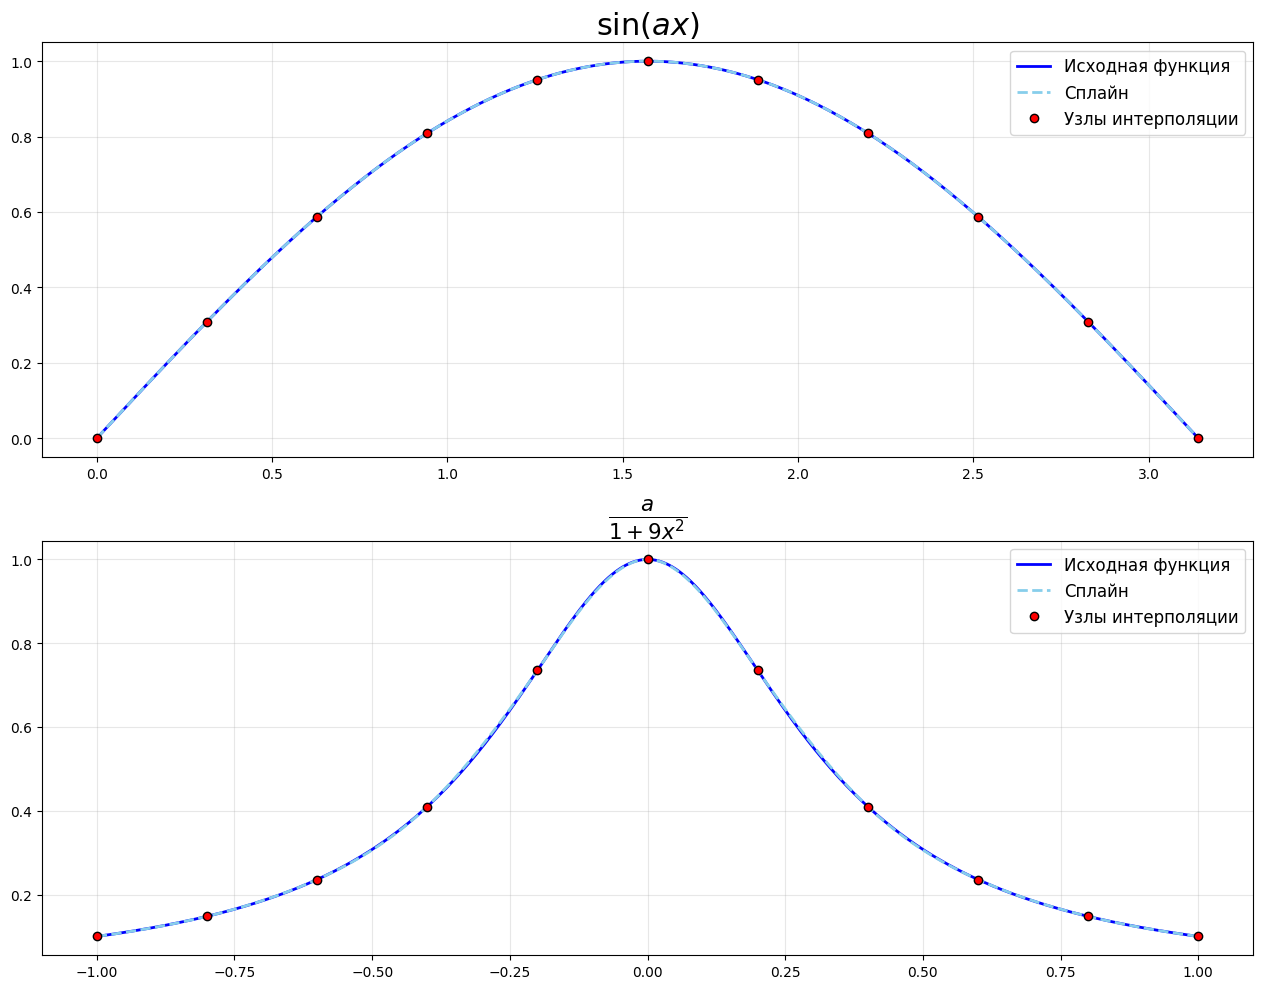

In [207]:
a = 1
N = 10

plt.figure(figsize=(25, 10))
for idx, (function, dfunction, ddfunction, function_name, start, stop) in enumerate(
    data
):
    # Получаем узлы интерполяции и наклоны
    x, y, m, h = calc(a, N, function, dfunction, ddfunction, function_name, start, stop)

    # Генерируем плотную сетку для гладкого отображения
    x_dense = np.linspace(start, stop, 1000)

    # Вычисляем значения исходной функции и сплайна на плотной сетке
    y_true = function(x_dense, a)
    y_spline = spline_eval(x_dense, x, y, m, h)

    # Строим графики
    plt.subplot(2, 2, idx * 2 + 1)
    plt.title(f"{function_name}", fontsize=22)
    plt.plot(x_dense, y_true, "blue", label="Исходная функция", linewidth=2)
    plt.plot(
        x_dense, y_spline, color="skyblue", linestyle="--", label="Сплайн", linewidth=2
    )
    plt.plot(
        x, y, "ro", label="Узлы интерполяции", markersize=6, markeredgecolor="black"
    )
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # # Дополнительно: график ошибки
    # plt.subplot(2, 2, idx * 2 + 2)
    # error = np.abs(y_true - y_spline)
    # plt.plot(x_dense, error, "red", label="Абсолютная ошибка", linewidth=2)
    # plt.title(f"Ошибка интерполяции: {function_name}", fontsize=22)
    # plt.xlabel("x")
    # plt.ylabel("|f(x) - S(x)|")
    # plt.legend(fontsize=12)
    # plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## При нефиксированном $N$

In [208]:
def experiment_vary_N(a, N_values, function, ddfunction, function_name, start, stop):
    max_errors = []
    rmse_errors = []
    
    for N in N_values:
        # Строим сплайн
        x, y, m, h = calc(a, N, function, None, ddfunction, function_name, start, stop)
        
        # Генерируем плотную сетку для оценки ошибки
        x_dense = np.linspace(start, stop, 1000)
        y_true = function(x_dense, a)
        y_spline = spline_eval(x_dense, x, y, m, h)
        
        # Вычисляем ошибки
        max_error, rmse, _ = calculate_error(x_dense, y_true, y_spline)
        max_errors.append(max_error)
        rmse_errors.append(rmse)
    
    return max_errors, rmse_errors

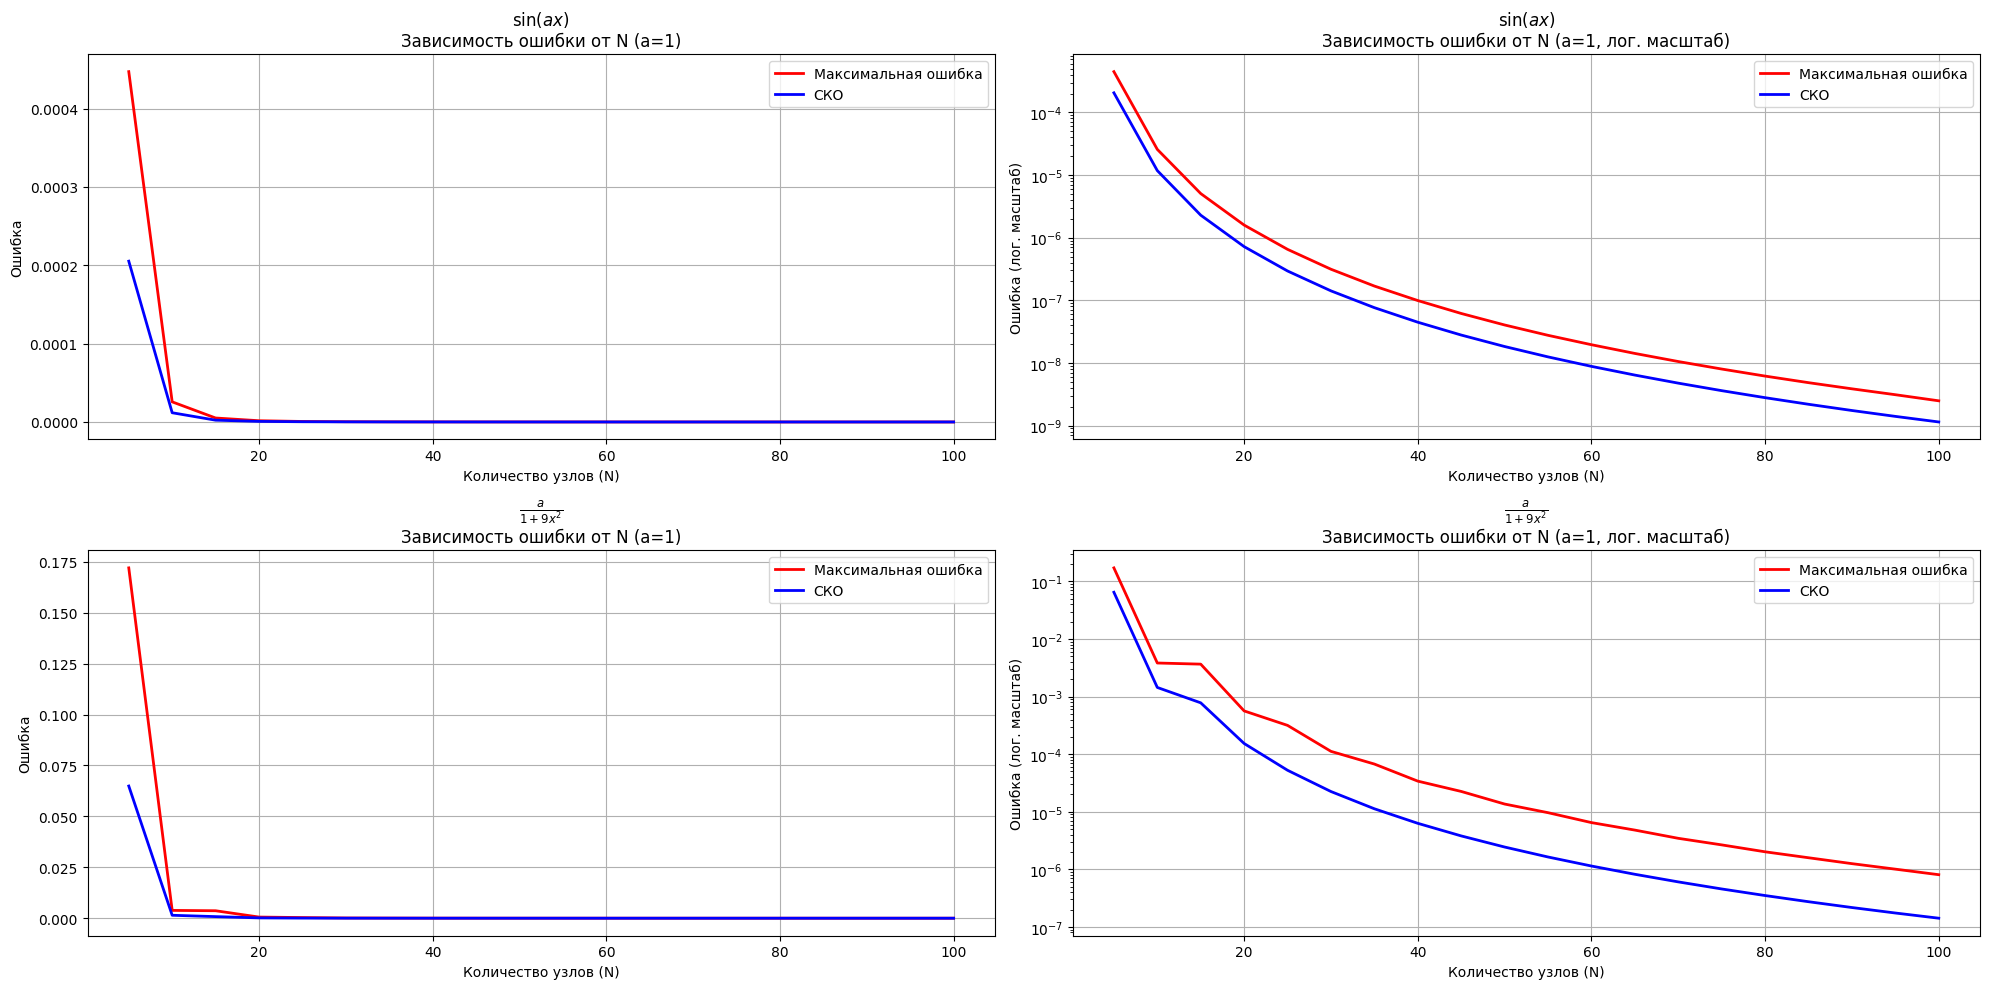

In [209]:
a = 1

N_values = np.arange(5, 100 + 1, 5)

plt.figure(figsize=(20, 10))
for idx, (function, dfunction, ddfunction, function_name, start, stop) in enumerate(
    data
):
    max_errors, rmse_errors = experiment_vary_N(
        a, N_values, function, ddfunction, function_name, start, stop
    )

    # Графики ошибок для эксперимента 1
    plt.subplot(2, 2, idx * 2 + 1)
    plt.plot(N_values, max_errors, "r-", label="Максимальная ошибка", linewidth=2)
    plt.plot(N_values, rmse_errors, "b-", label="СКО", linewidth=2)
    plt.xlabel("Количество узлов (N)")
    plt.ylabel("Ошибка")
    plt.title(f"{function_name}\nЗависимость ошибки от N (a={a})")
    plt.legend()
    plt.grid(True)

    # Логарифмический масштаб для лучшей визуализации
    plt.subplot(2, 2, idx * 2 + 2)
    plt.semilogy(N_values, max_errors, "r-", label="Максимальная ошибка", linewidth=2)
    plt.semilogy(N_values, rmse_errors, "b-", label="СКО", linewidth=2)
    plt.xlabel("Количество узлов (N)")
    plt.ylabel("Ошибка (лог. масштаб)")
    plt.title(f"{function_name}\nЗависимость ошибки от N (a={a}, лог. масштаб)")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## При фиксированном $a$

In [210]:
def experiment_vary_a(a_values, N, function, ddfunction, function_name, start, stop):
    max_errors = []
    rmse_errors = []
    
    for a in a_values:
        # Строим сплайн
        x, y, m, h = calc(a, N, function, None, ddfunction, function_name, start, stop)
        
        # Генерируем плотную сетку для оценки ошибки
        x_dense = np.linspace(start, stop, 1000)
        y_true = function(x_dense, a)
        y_spline = spline_eval(x_dense, x, y, m, h)
        
        # Вычисляем ошибки
        max_error, rmse, _ = calculate_error(x_dense, y_true, y_spline)
        max_errors.append(max_error)
        rmse_errors.append(rmse)
    
    return max_errors, rmse_errors

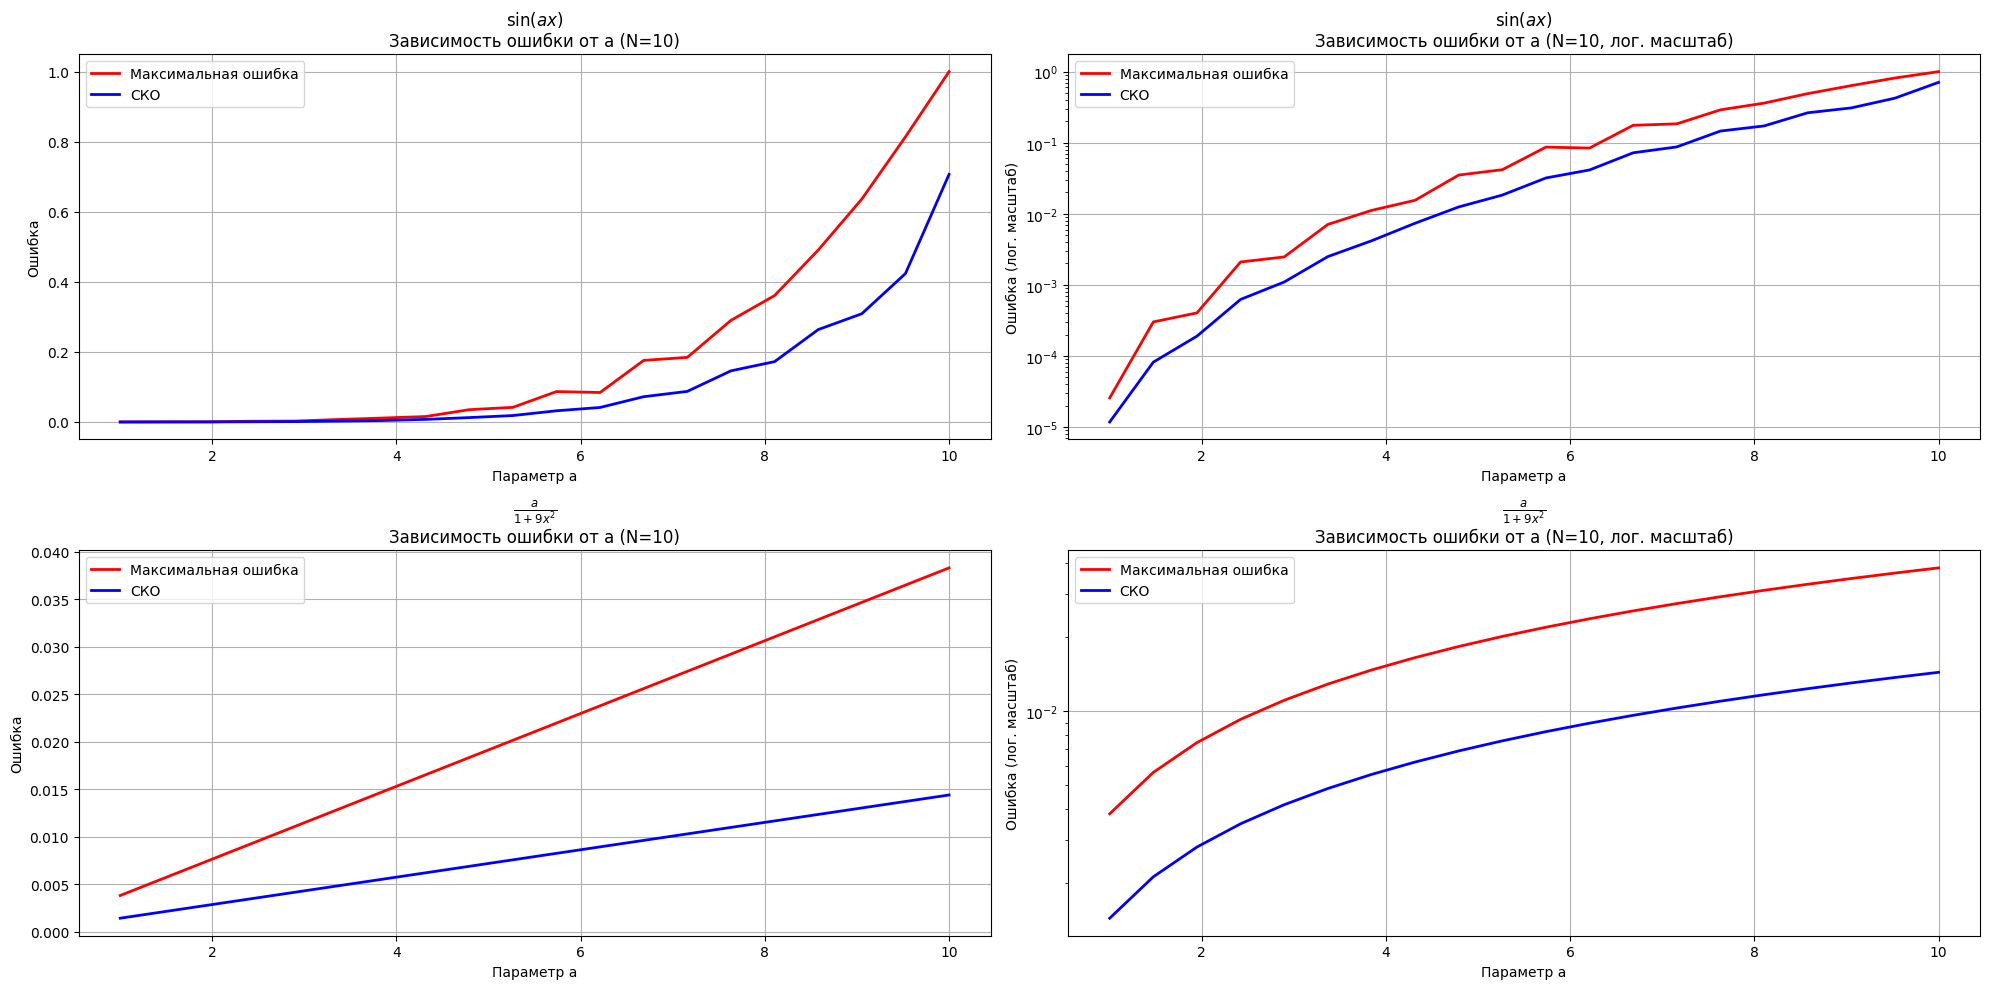

In [211]:
a_values = np.linspace(1, 10, 20)  # a от 1 до 10
    
plt.figure(figsize=(20, 10))

for idx, (function, dfunction, ddfunction, function_name, start, stop) in enumerate(data):
    max_errors, rmse_errors = experiment_vary_a(a_values, N, function, ddfunction, function_name, start, stop)
    
    # Графики ошибок для эксперимента 2
    plt.subplot(2, 2, idx*2 + 1)
    plt.plot(a_values, max_errors, 'r-', label='Максимальная ошибка', linewidth=2)
    plt.plot(a_values, rmse_errors, 'b-', label='СКО', linewidth=2)
    plt.xlabel('Параметр a')
    plt.ylabel('Ошибка')
    plt.title(f'{function_name}\nЗависимость ошибки от a (N={N})')
    plt.legend()
    plt.grid(True)
    
    # Логарифмический масштаб для лучшей визуализации
    plt.subplot(2, 2, idx*2 + 2)
    plt.semilogy(a_values, max_errors, 'r-', label='Максимальная ошибка', linewidth=2)
    plt.semilogy(a_values, rmse_errors, 'b-', label='СКО', linewidth=2)
    plt.xlabel('Параметр a')
    plt.ylabel('Ошибка (лог. масштаб)')
    plt.title(f'{function_name}\nЗависимость ошибки от a (N={N}, лог. масштаб)')
    plt.legend()
    plt.grid(True)
    
plt.tight_layout()
plt.show()